<h1 style="color: green;">Home task</h1>

In [239]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical


## Load the Data

In [241]:
def load_dataset():
    fn = '/Users/user/Desktop/Camp2025/lesson_25/data/train_signs.h5'
    train_dataset = h5py.File(fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:])
    Y_train = np.array(train_dataset["train_set_y"][:]) 

    fn = '/Users/user/Desktop/Camp2025/lesson_25/data/test_signs.h5'
    test_dataset =  h5py.File(fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:]) 
    Y_test = np.array(test_dataset["test_set_y"][:]) 

    classes = np.array(test_dataset["list_classes"][:]) 
    
    Y_train = Y_train.reshape((1, Y_train.shape[0]))
    Y_test = Y_test.reshape((1, Y_test.shape[0]))
    
    return X_train, Y_train, X_test, Y_test, classes
X_train, Y_train, X_test, Y_test, classes = load_dataset()

print ('train_data.shape=', X_train.shape)
print ('train_labels.shape=',  Y_train.shape)
print ('test_data.shape=', X_test.shape)
print ('test_labels.shape=', Y_test.shape)

train_data.shape= (1080, 64, 64, 3)
train_labels.shape= (1, 1080)
test_data.shape= (120, 64, 64, 3)
test_labels.shape= (1, 120)


## Review the data

In [243]:
def display_samples_in_grid(X, n_rows, n_cols= None, y = None ):
    if n_cols is None:
        n_cols= n_rows
    indices = np.random.randint(0, len(X),n_rows*n_cols)
    for i in range (n_rows):
        for j in range (n_cols):
            index = n_cols*i+j
            ax = plt.subplot(n_rows,n_cols,index+1)
            ax.imshow(X[indices[index]], cmap='Greys')
            if not (y is None):
                plt.title(y[indices[index]])
            plt.axis('off')

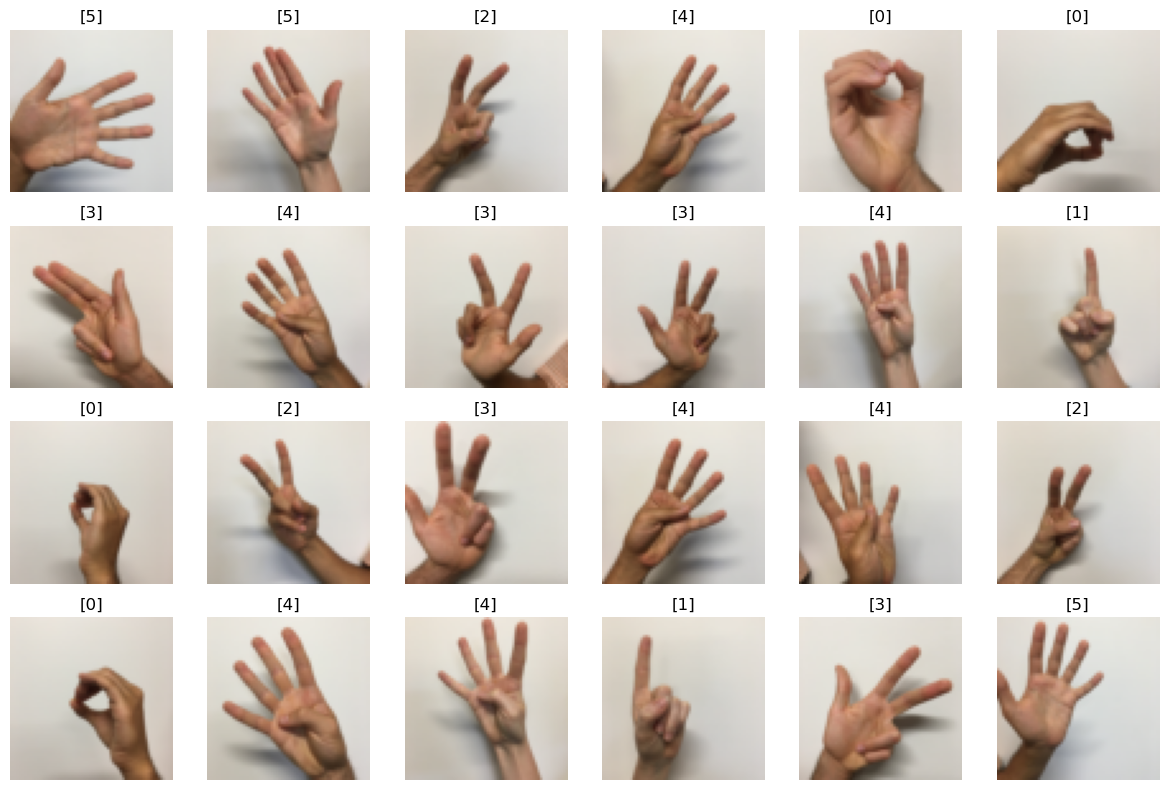

In [244]:
nClasses = len(classes)
plt.figure(figsize= (12,8))
display_samples_in_grid(train_data, n_rows=4, n_cols=6, y= train_labels.T)
plt.tight_layout(h_pad=1, w_pad=1)

## Process the data

In [246]:
dimData = np.prod(X_train.shape[1:])
X_train = X_train.reshape(X_train.shape[0], dimData)
X_test = X_test.reshape(X_test.shape[0], dimData)

In [247]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
 
X_train /= 255
X_test /= 255

In [248]:
Y_train_one_hot = to_categorical(Y_train[0])
Y_test_one_hot = to_categorical(Y_test[0])
 
print('Original label [0] : ', Y_train[0])
print('After conversion to categorical ( one-hot ) : ', Y_train_one_hot[0])

Original label [0] :  [5 0 2 ... 2 4 5]
After conversion to categorical ( one-hot ) :  [0. 0. 0. 0. 0. 1.]


In [249]:
def Graphic(history):
    plt.figure(figsize=[8, 6])
    plt.plot(history.history['loss'], 'r', linewidth=3.0)
    plt.plot(history.history['val_loss'], 'b', linewidth=3.0)
    plt.legend(['Training loss', 'Testing Loss'], fontsize=18)
    plt.xlabel('Epochs ', fontsize=16)
    plt.ylabel('Loss', fontsize=16)
    plt.title('Loss Curves', fontsize=16)

    plt.figure(figsize=[8, 6])
    plt.plot(history.history['accuracy'], 'r', linewidth=3.0)
    plt.plot(history.history['val_accuracy'], 'b', linewidth=3.0)
    plt.legend(['Training Accuracy', 'Testing Accuracy'], fontsize=18)
    plt.xlabel('Epochs ', fontsize=16)
    plt.ylabel('Accuracy', fontsize=16)
    plt.title('Accuracy Curves', fontsize=16)

## Create the model

In [251]:
from keras.models import Sequential
from keras.layers import Dense
import keras
 
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(dimData,)))
model.add(Dense(512, activation='relu'))
model.add(Dense(nClasses, activation='softmax'))

/Library/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [252]:
class MyModel(keras.Model):
    def __init__(self, nClasses):
        super().__init__()
        self.dense1 = Dense(512, activation="relu")
        self.dense2 = Dense(512, activation="relu")
        self.classify = Dense(nClasses, activation='softmax')
        
    def call(self, inputs, training=False):
        x = self.dense1(inputs)
        x = self.dense2(x)
        return self.classify(x)

model = MyModel(6)



In [253]:
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])


In [254]:
history = model.fit(X_train, Y_train_one_hot, batch_size=256, epochs=30, verbose=1, 
                   validation_data=(X_test, Y_test_one_hot))

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.1837 - loss: 43.4633 - val_accuracy: 0.1667 - val_loss: 19.5313
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.1681 - loss: 16.8266 - val_accuracy: 0.1667 - val_loss: 4.3028
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.1689 - loss: 4.3410 - val_accuracy: 0.1667 - val_loss: 2.5495
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.1782 - loss: 2.2155 - val_accuracy: 0.1667 - val_loss: 2.3429
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.2052 - loss: 2.1076 - val_accuracy: 0.2167 - val_loss: 1.8848
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.1792 - loss: 1.9188 - val_accuracy: 0.1667 - val_loss: 2.6969
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.1849 - loss: 2.2798 - val_accuracy: 0.1667 - val_loss: 1.9952
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.1673 - loss: 1.9855 - val_accuracy: 0.1667 - val_loss: 1.8

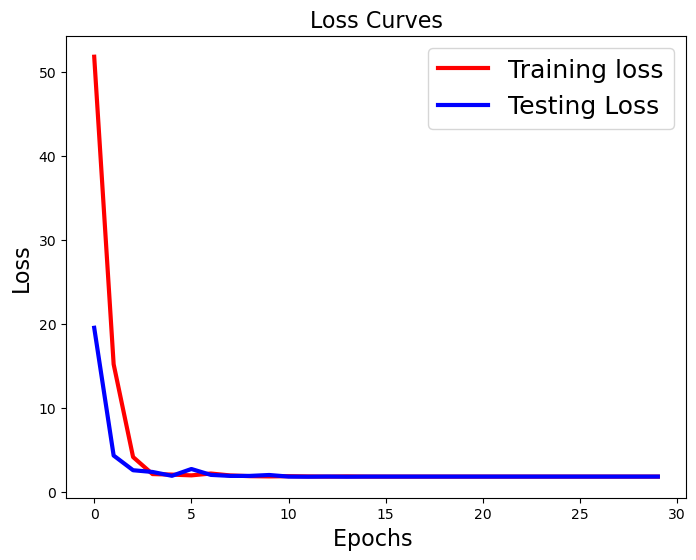

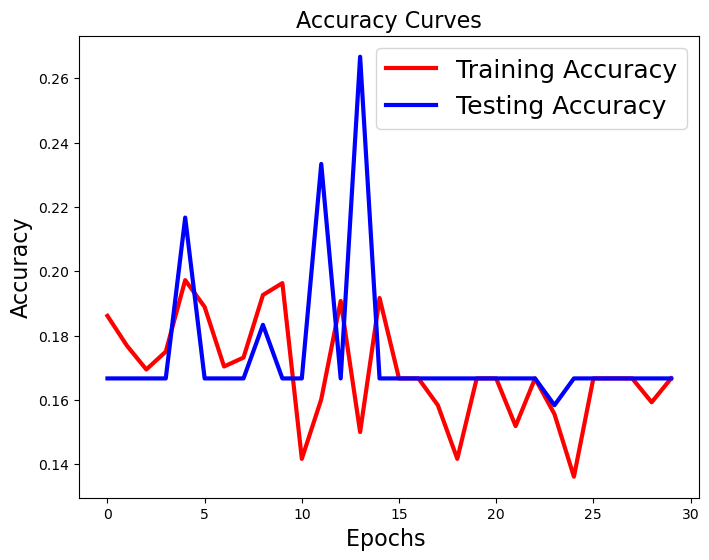

In [255]:
Graphic(history)


Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.1686 - loss: 5.1297 - val_accuracy: 0.1667 - val_loss: 3.5861
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.1787 - loss: 3.0273 - val_accuracy: 0.1667 - val_loss: 1.8397
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.1769 - loss: 1.8185 - val_accuracy: 0.1667 - val_loss: 1.9894
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.1571 - loss: 1.8970 - val_accuracy: 0.1667 - val_loss: 1.9061
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.1762 - loss: 1.8849 - val_accuracy: 0.1667 - val_loss: 1.8637
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.1402 - loss: 1.9155 - val_accuracy: 0.1667 - val_loss: 1.9545
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.1452 - loss: 1.9002 - val_accuracy: 0.1667 - val_loss: 1.8597
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.1671 - loss: 1.8217 - val_accuracy: 0.1667 - val_loss: 1.9693

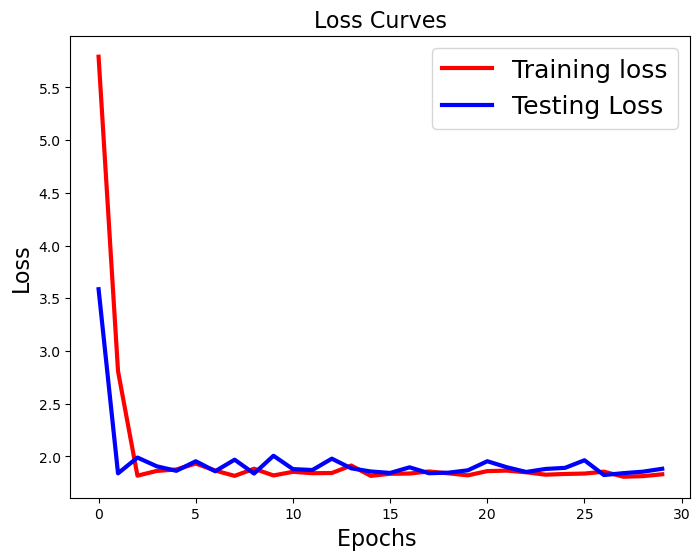

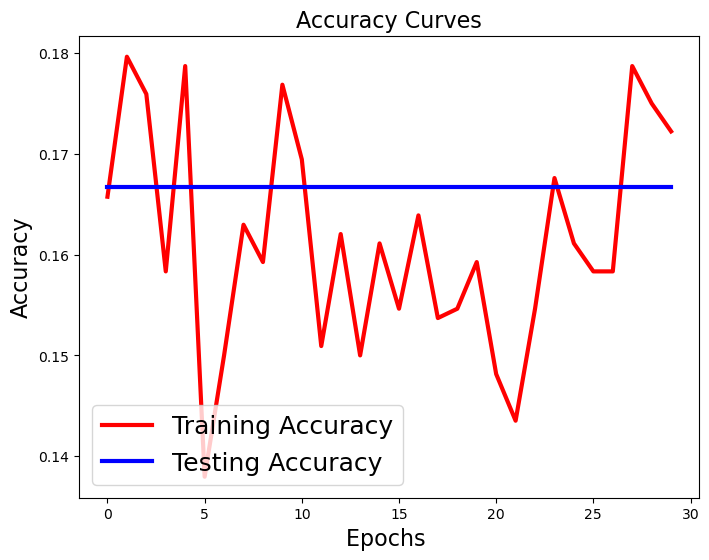

In [256]:
class MyModelTanh(keras.Model):
    def __init__(self, nClasses):
        super().__init__()
        self.dense1 = Dense(512, activation="tanh")
        self.dense2 = Dense(512, activation="tanh")
        self.classify = Dense(nClasses, activation='softmax')

    def call(self, inputs, training=False):
        x = self.dense1(inputs)
        x = self.dense2(x)
        return self.classify(x)

model = MyModelTanh(6)
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, Y_train_one_hot, batch_size=256, epochs=30, verbose=1, 
                   validation_data=(X_test, Y_test_one_hot))
Graphic(history)


Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.1629 - loss: 32.3943 - val_accuracy: 0.1667 - val_loss: 13.8504
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.1647 - loss: 9.7675 - val_accuracy: 0.2000 - val_loss: 1.9642
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.1667 - loss: 2.0921 - val_accuracy: 0.1667 - val_loss: 1.9571
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.1961 - loss: 1.9707 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.1686 - loss: 1.7918 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.1516 - loss: 1.7918 - val_accuracy: 0.1917 - val_loss: 1.7904
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.1717 - loss: 1.7913 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.1666 - loss: 1.7918 - val_accuracy: 0.1667 - val_loss: 1.7

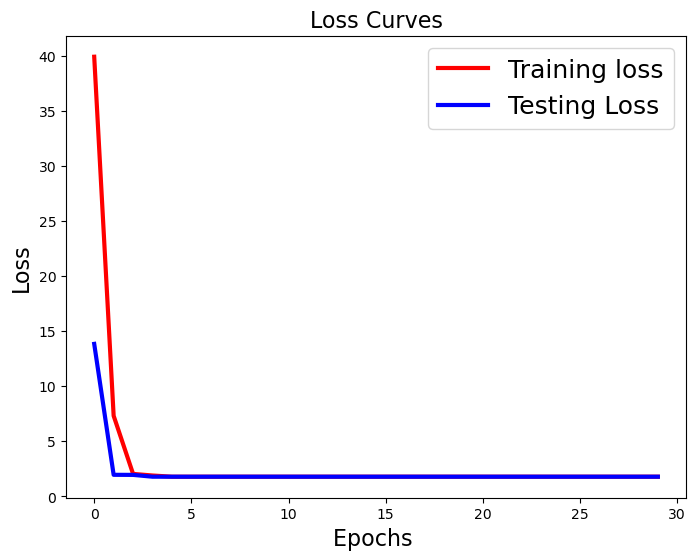

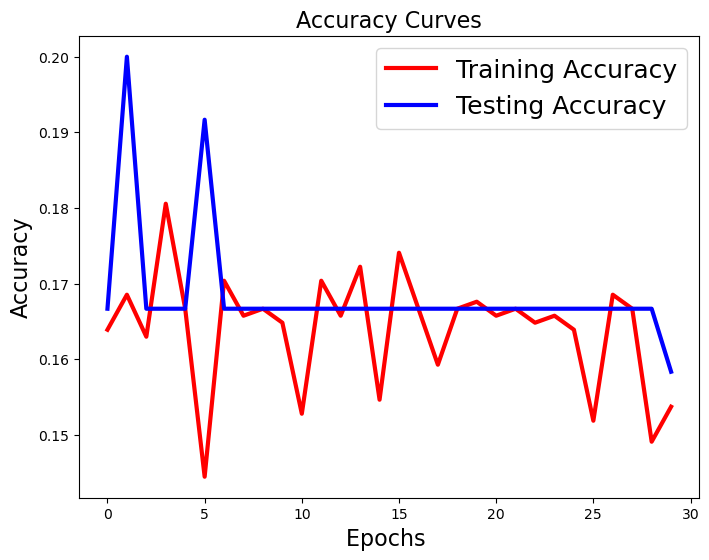

In [257]:
from keras.layers import Dropout

class MyModelDropout(keras.Model):
    def __init__(self, nClasses):
        super().__init__()
        self.dense1 = Dense(512, activation="relu")
        self.dropout1 = Dropout(0.3)
        self.dense2 = Dense(512, activation="relu")
        self.dropout2 = Dropout(0.3)
        self.classify = Dense(nClasses, activation='softmax')

    def call(self, inputs, training=False):
        x = self.dense1(inputs)
        if training:
            x = self.dropout1(x, training=training)
        x = self.dense2(x)
        if training:
            x = self.dropout2(x, training=training)
        return self.classify(x)

model = MyModelDropout(6)
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, Y_train_one_hot, batch_size=256, epochs=30, verbose=1, 
                   validation_data=(X_test, Y_test_one_hot))
Graphic(history)


Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - accuracy: 0.1671 - loss: 2.5284 - val_accuracy: 0.1667 - val_loss: 1.9345
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.1745 - loss: 2.0503 - val_accuracy: 0.1667 - val_loss: 1.8717
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.1451 - loss: 1.9893 - val_accuracy: 0.1667 - val_loss: 1.8565
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.1683 - loss: 2.0009 - val_accuracy: 0.1667 - val_loss: 1.8359
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.2150 - loss: 1.8948 - val_accuracy: 0.1667 - val_loss: 1.8271
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.1723 - loss: 1.9625 - val_accuracy: 0.1667 - val_loss: 1.8212
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.1762 - loss: 1.9220 - val_accuracy: 0.1667 - val_loss: 1.8302
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.1545 - loss: 1.9277 - val_accuracy: 0.1667 - val_loss: 1.84

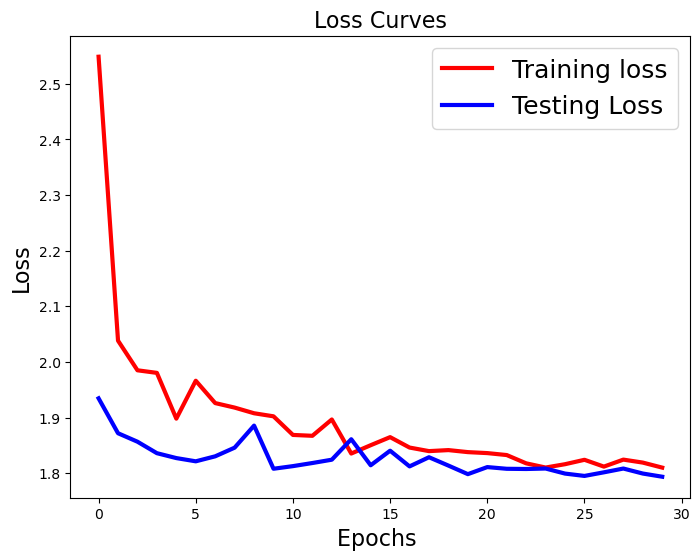

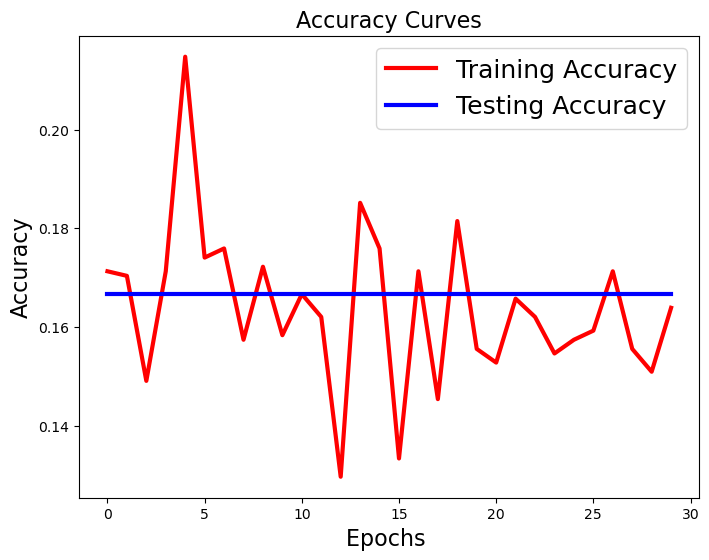

In [258]:
class MyModelSigmoid(keras.Model):
    def __init__(self, nClasses):
        super().__init__()
        self.dense1 = Dense(512, activation="sigmoid")
        self.dropout1 = Dropout(0.5)
        self.dense2 = Dense(512, activation="sigmoid")
        self.dropout2 = Dropout(0.5)
        self.classify = Dense(nClasses, activation='softmax')

    def call(self, inputs, training=False):
        x = self.dense1(inputs)
        if training:
            x = self.dropout1(x, training=training)
        x = self.dense2(x)
        if training:
            x = self.dropout2(x, training=training)
        return self.classify(x)

model = MyModelSigmoid(6)
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, Y_train_one_hot, batch_size=256, epochs=30, verbose=1, 
                   validation_data=(X_test, Y_test_one_hot))
Graphic(history)


Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.1673 - loss: 26.7530 - val_accuracy: 0.1667 - val_loss: 30.6047
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.1781 - loss: 23.2645 - val_accuracy: 0.1667 - val_loss: 3.7618
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.1949 - loss: 3.0388 - val_accuracy: 0.1667 - val_loss: 3.2806
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.1498 - loss: 2.9735 - val_accuracy: 0.1667 - val_loss: 2.3219
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.1439 - loss: 2.1749 - val_accuracy: 0.1667 - val_loss: 2.1340
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.1764 - loss: 1.9847 - val_accuracy: 0.1833 - val_loss: 1.9523
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.2183 - loss: 1.8453 - val_accuracy: 0.1667 - val_loss: 1.8294
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.1576 - loss: 1.9063 - val_accuracy: 0.1667 - val_loss: 1.9

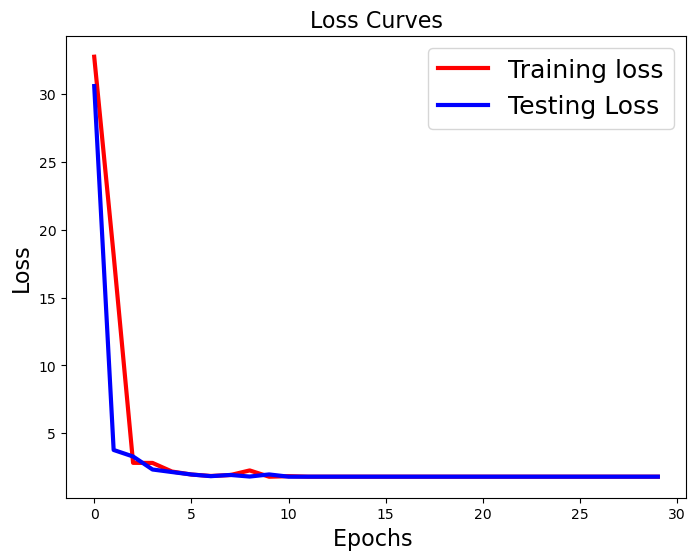

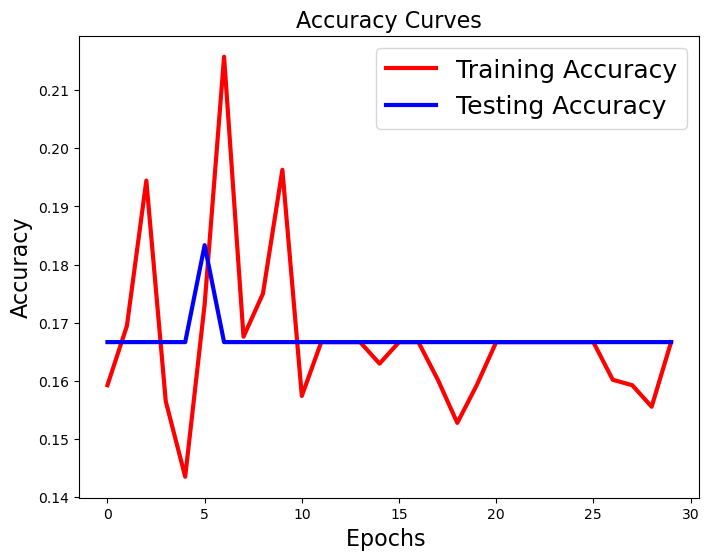

In [259]:
class MyModelDeep(keras.Model):
    def __init__(self, nClasses):
        super().__init__()
        self.dense1 = Dense(512, activation="relu")
        self.dense2 = Dense(512, activation="relu")
        self.dense3 = Dense(256, activation="relu")
        self.classify = Dense(nClasses, activation='softmax')

    def call(self, inputs, training=False):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        return self.classify(x)

model = MyModelDeep(6)
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, Y_train_one_hot, batch_size=256, epochs=30, verbose=1, 
                   validation_data=(X_test, Y_test_one_hot))
Graphic(history)
